In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
import os
import json
from datetime import datetime

from tavily import TavilyClient

from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain.agents.middleware import TodoListMiddleware

from deepagents.middleware.subagents import SubAgentMiddleware

CURRENT_DATE = datetime.now().strftime("%Y-%m-%d")

# ============================================================
# LLM
# ============================================================

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0
)


# ============================================================
# FILE TOOLS
# ============================================================

@tool
def read_file(path: str) -> str:
    """Read a file and return its contents."""
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


@tool
def write_file(path: str, content: str) -> str:
    """Write content to an existing file."""
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

    return f"Successfully wrote content to {path}"


@tool
def make_directory(path: str) -> str:
    """Create a directory if it does not exist."""
    os.makedirs(path, exist_ok=True)
    return f"Created directory: {path}"


@tool
def create_file(path: str, content: str) -> str:
    """Create a file with the specified content."""
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)

    return f"Created file: {path}"


@tool
def delete_file(path: str) -> str:
    """Delete a file."""
    os.remove(path)
    return f"Deleted file: {path}"


# ============================================================
# WEB SEARCH TOOL
# ============================================================

tavily_client = TavilyClient(
    api_key=os.getenv("TAVILY_API_KEY")
)


@tool
def web_search(query: str, max_results: int = 5) -> str:
    """
    Search the web for current information.

    Use for:
    - News
    - Sports
    - Live matches
    - Weather
    - Current events
    - Recent releases
    """

    print("\n" + "=" * 80)
    print("TAVILY SEARCH CALLED")
    print("QUERY:", query)
    print("=" * 80 + "\n")

    response = tavily_client.search(
        query=query,
        search_depth="advanced",
        max_results=max_results,
        include_answer=False,      # IMPORTANT
        include_raw_content=False,
    )

    return json.dumps(response, indent=2)


# ============================================================
# MAIN AGENT
# ============================================================

agent = create_agent(
    name="HelpfulAssistant",
    model=llm,
    tools=[],
    system_prompt=f"""
Today's date is {CURRENT_DATE}.

You are a helpful assistant that delegates work to specialized subagents.

Available subagents:

1. file_manager
2. python_developer_agent
3. research_agent

IMPORTANT:

- For live sports, current events, news, weather,
  ongoing matches, stock prices, or anything
  time-sensitive, ALWAYS delegate to research_agent.

- Never answer time-sensitive questions from memory.

- Your knowledge may be outdated.


IMPORTANT RULES:

- For ANY question involving:
  * current events
  * sports scores
  * live matches
  * FIFA World Cup
  * news
  * weather
  * stock prices
  * recent releases
  * anything that may have changed recently

  ALWAYS delegate to research_agent.

- Never answer real-time questions from your own knowledge.

- Use the most appropriate subagent whenever specialized work is needed.
""",
    middleware=[
        TodoListMiddleware(),
        SubAgentMiddleware(
            backend="local",
            subagents=[
                {
                    "name": "file_manager",
                    "description": (
                        "Handles file operations including creating, "
                        "reading, writing, deleting files and creating folders."
                    ),
                    "system_prompt": """
You are a file management specialist.

Your responsibilities:
- Create files
- Read files
- Write files
- Delete files
- Create directories

Always use available tools.
""",
                    "tools": [
                        read_file,
                        write_file,
                        create_file,
                        delete_file,
                        make_directory,
                    ],
                    "model": llm,
                    "middleware": [
                        TodoListMiddleware()
                    ],
                },
                {
                    "name": "python_developer_agent",
                    "description": (
                        "Python programming specialist."
                    ),
                    "system_prompt": """
You are a senior Python developer.

You help with:
- Writing code
- Reviewing code
- Debugging
- Refactoring
- Explaining Python concepts
""",
                    "tools": [
                        read_file,
                        write_file,
                        create_file,
                        delete_file,
                    ],
                    "model": llm,
                    "middleware": [
                        TodoListMiddleware()
                    ],
                },
                {
    "name": "research_agent",
    "description": "Searches the internet for current information.",
    "system_prompt": """
You are a professional internet researcher.

RULES:

1. Always use web_search before answering.

2. Treat web_search output as the source of truth.

3. Never override search results using your own memory.

4. Never contradict search results.

5. Summarize only what the search results support.

6. If search results are insufficient,
   explicitly say so.
""",
    "tools": [web_search],
    "model": llm,
    "middleware": []
},
            ],
        ),
    ],
)

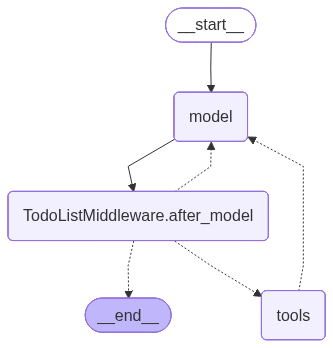

In [3]:
agent

In [5]:
# ============================================================
# TEST
# ============================================================

response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="Create a folder called python_project, then create a file called demo.py in it. Which match is currently going on in FIFA World Cup 2026?"
            )
        ]
    }
)

print(response["messages"][-1].content)

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'file_manager' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<tool_call>\n{"name": "file_manager", "arguments": {"action": "create_folder", "path": "python_project"}}\n</tool_call>'}}